## Part 2

In [18]:
#Import needed libraries
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub
import numpy as np
from collections import defaultdict

#Sklearn imports, used for ML models and evaluation metrics
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.neighbors import LocalOutlierFactor


In [19]:
#Import dataset and preview
path = kagglehub.dataset_download(
    "uciml/red-wine-quality-cortez-et-al-2009"
)

df = pd.read_csv(f"{path}/winequality-red.csv")

#Preview the dataset and info about the columns and data types
print(df.head())
print(df.info())

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8        5  
2      9.8        5 

In [20]:
#Train/test/eval splits
train_reduced, test_df = train_test_split(df, test_size=0.15, random_state=42)
train_df, val_df = train_test_split(train_reduced, test_size=0.15, random_state=42)

print(f"Total samples:         {len(df)}")
print(f"Holdout test set:      {len(test_df)} ({len(test_df)/len(df):.0%})")
print(f"train_reduced:         {len(train_reduced)} ({len(train_reduced)/len(df):.0%})")
print(f"  Train:               {len(train_df)} ({len(train_df)/len(df):.0%})")
print(f"  Validation:          {len(val_df)} ({len(val_df)/len(df):.0%})")

Total samples:         1599
Holdout test set:      240 (15%)
train_reduced:         1359 (85%)
  Train:               1155 (72%)
  Validation:          204 (13%)


In [ ]:
#Data cleaning

#Check for any null values in dataset accross features


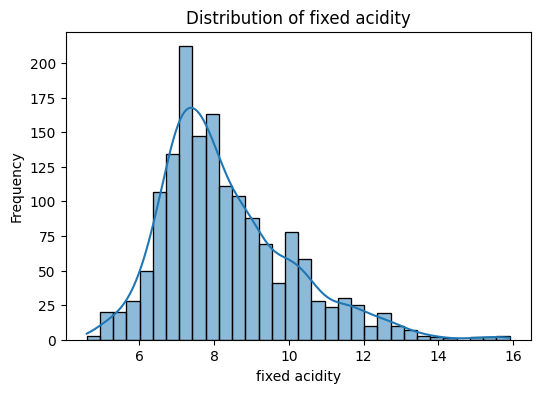

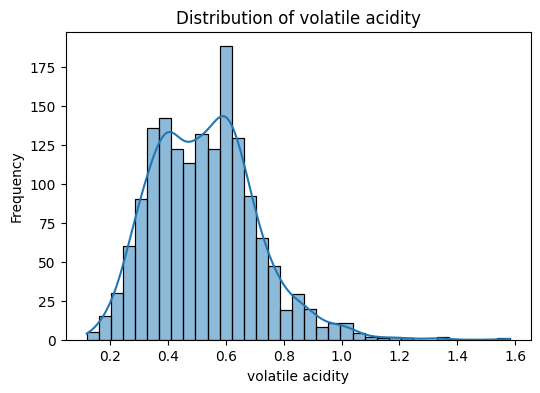

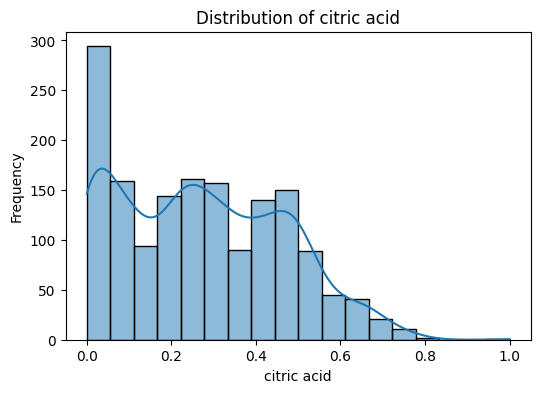

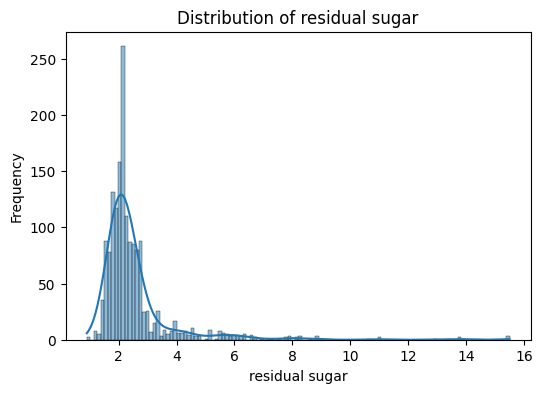

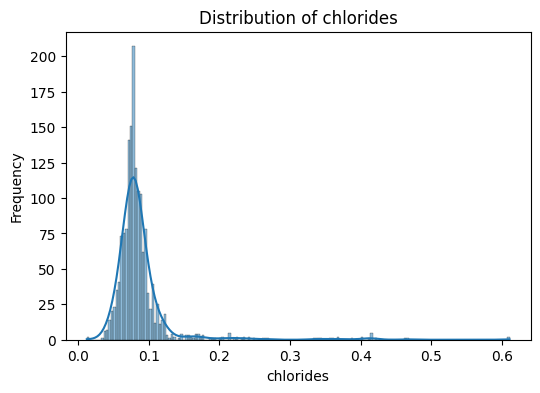

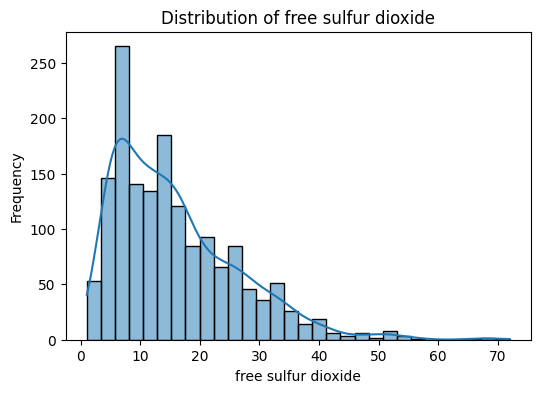

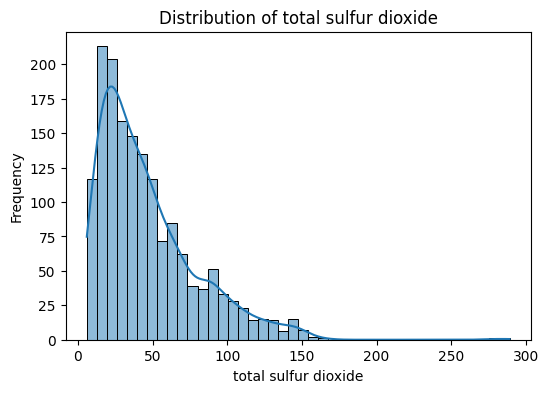

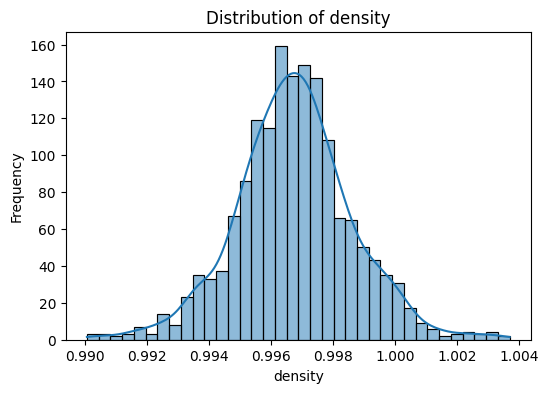

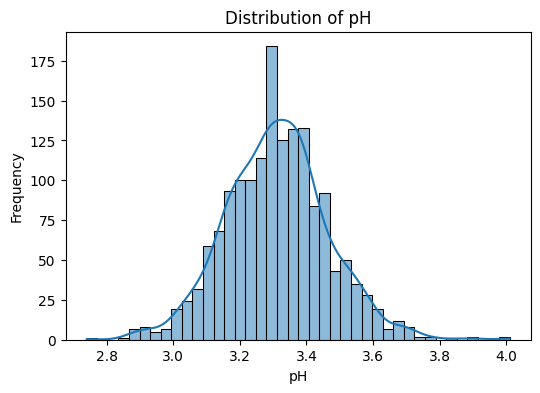

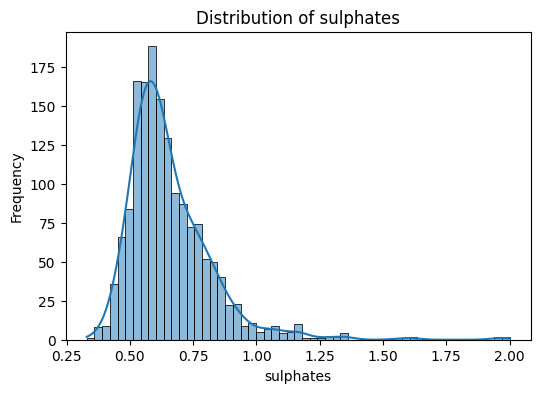

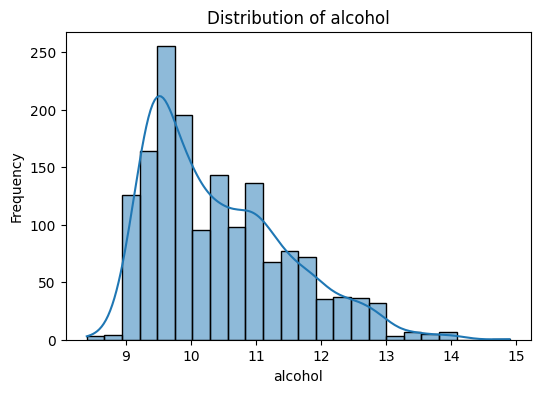

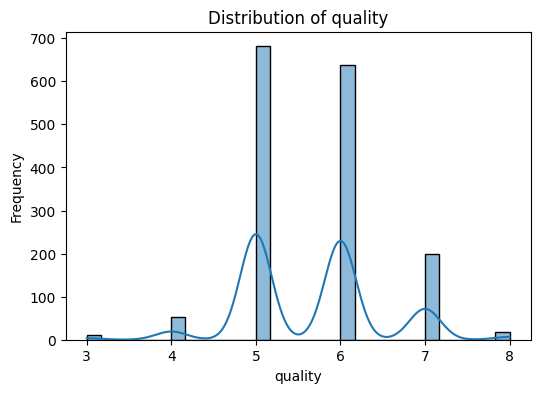

In [21]:
#Visualize distribution of all features
for col in df.columns:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()



/Users/jonathanc/dev/school/Data_Science/DataScienceA2/.venv/lib/python3.9/site-packages/sklearn/neighbors/_lof.py:322: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


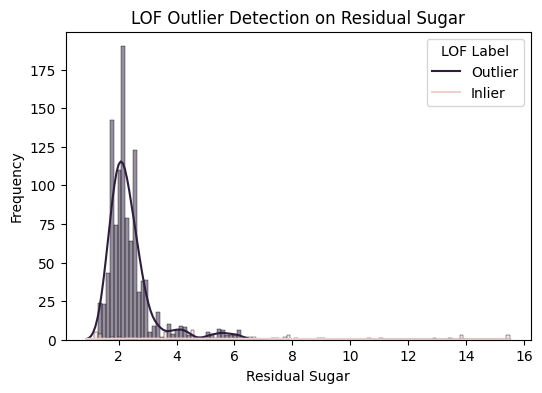

In [ ]:
#Perform LOF to detect outliers in residual sugar

#First calculate mean for imputation
mean_residual_sugar = train_df['residual sugar'].mean()

#Perform LOF on residual sugar
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
train_df['lof_residual_sugar'] = lof.fit_predict(train_df[['residual sugar']].fillna(mean_residual_sugar))

#Visualize LOF results
plt.figure(figsize=(6, 4))
sns.histplot(data=train_df, x='residual sugar', kde=True, hue='lof_residual_sugar')
plt.title("LOF Outlier Detection on Residual Sugar")
plt.xlabel("Residual Sugar")
plt.ylabel("Frequency")
plt.legend(title='LOF Label', labels=['Outlier', 'Inlier'])
plt.show()

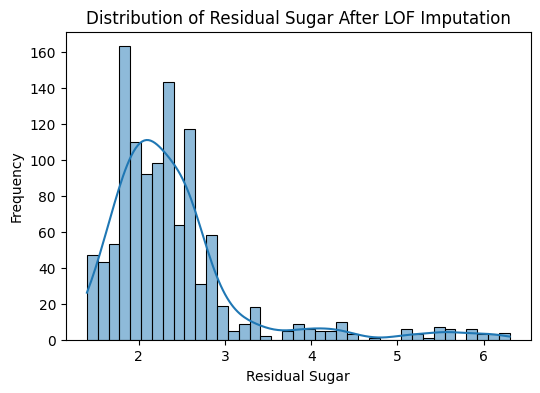

In [23]:
#Imputate outliers with mean
train_df.loc[train_df['lof_residual_sugar'] == -1, 'residual sugar'] = mean_residual_sugar

#Re-visualize distribution of residual sugar after imputation
plt.figure(figsize=(6, 4))
sns.histplot(train_df['residual sugar'], kde=True)
plt.title("Distribution of Residual Sugar After LOF Imputation")
plt.xlabel("Residual Sugar")
plt.ylabel("Frequency")
plt.show()